## Experiment Objective

Evaluate whether a pricing change improves conversion without negatively impacting retention.

## Hypothesis

Changing the subscription pricing will increase conversion rate without significantly reducing retention.

## Experiment Design

- Population: 50,000 users
- Groups:
  - Control: Existing pricing
  - Treatment: Modified pricing
- Assignment: Random split between control and treatment

## Success Metrics

- Primary metric: Conversion rate
- Guardrail metric: Retention rate (to ensure no negative user impact)

In [2]:
import numpy as np
import pandas as pd

In [3]:
np.random.seed(42)

n = 50000

# Basic user features
df = pd.DataFrame({
    "user_id": range(1, n+1),
    "country": np.random.choice(["US", "SE", "IN", "UK"], n, p=[0.4, 0.2, 0.25, 0.15]),
    "device": np.random.choice(["iOS", "Android", "Web"], n, p=[0.4, 0.4, 0.2]),
    "tenure_months": np.random.randint(1, 24, n)
})

# Assign experiment groups
df["group"] = np.random.choice(["control", "treatment"], n)

# Base conversion probability
base_conversion = 0.10

# Adjust based on features
df["conversion_prob"] = base_conversion \
    + (df["device"] == "iOS") * 0.02 \
    + (df["country"] == "US") * 0.015 \
    + (df["tenure_months"] > 12) * 0.01

# Treatment uplift
df.loc[df["group"] == "treatment", "conversion_prob"] += 0.02

# Clip probabilities
df["conversion_prob"] = df["conversion_prob"].clip(0, 1)

# Simulate conversion
df["converted"] = np.random.binomial(1, df["conversion_prob"])

# Retention probability (only for converted users)
df["retention_prob"] = 0.6 \
    + (df["tenure_months"] > 12) * 0.1 \
    + (df["device"] == "iOS") * 0.05

df["retention_prob"] = df["retention_prob"].clip(0, 1)

df["retained"] = np.where(
    df["converted"] == 1,
    np.random.binomial(1, df["retention_prob"]),
    0
)

# Drop probability columns
df = df.drop(columns=["conversion_prob", "retention_prob"])

print(df.head())
print(df["group"].value_counts())

   user_id country   device  tenure_months      group  converted  retained
0        1      US      Web              2    control          0         0
1        2      UK  Android              8    control          0         0
2        3      IN      iOS             15    control          0         0
3        4      SE  Android             17  treatment          0         0
4        5      US  Android              6  treatment          0         0
group
treatment    25158
control      24842
Name: count, dtype: int64


In [4]:
# Check experiment results (conversion + retention)
# checking if treatment actually performs better than control
summary = df.groupby("group").agg(
    users=("user_id", "count"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean"),
    retained_users=("retained", "sum")
)

summary["retention_rate"] = summary["retained_users"] / summary["conversions"]

print(summary)

           users  conversions  conversion_rate  retained_users  retention_rate
group                                                                         
control    24842         2946         0.118589            2001        0.679226
treatment  25158         3507         0.139399            2313        0.659538


In [5]:
# Calculate uplift clearly

conversion_uplift = summary.loc["treatment", "conversion_rate"] - summary.loc["control", "conversion_rate"]
retention_uplift = summary.loc["treatment", "retention_rate"] - summary.loc["control", "retention_rate"]

print("Conversion uplift:", conversion_uplift)
print("Retention uplift:", retention_uplift)

Conversion uplift: 0.020809512781883338
Retention uplift: -0.01968800252274039


In [6]:
# Check randomization
# check if control vs treatment have similar user mix.
pd.crosstab(df["group"], df["device"], normalize="index")

device,Android,Web,iOS
group,,,
control,0.405563,0.197609,0.396828
treatment,0.399237,0.201526,0.399237


In [7]:
# Statistical test (conversion)
# Check if conversion uplift is statistically significant (not random noise)
from statsmodels.stats.proportion import proportions_ztest

conversions = [summary.loc["treatment", "conversions"], summary.loc["control", "conversions"]]
users = [summary.loc["treatment", "users"], summary.loc["control", "users"]]

stat, pval = proportions_ztest(conversions, users)

print("Z-stat:", stat)
print("P-value:", pval)

Z-stat: 6.939342068126656
P-value: 3.939302324260859e-12


In [8]:
# Statistical test (retention)
# Check if retention drop is real or just noise
converted_df = df[df["converted"] == 1]

ret_summary = converted_df.groupby("group").agg(
    retained=("retained", "sum"),
    total=("retained", "count")
)

from statsmodels.stats.proportion import proportions_ztest

retained = [ret_summary.loc["treatment", "retained"], ret_summary.loc["control", "retained"]]
total = [ret_summary.loc["treatment", "total"], ret_summary.loc["control", "total"]]

stat, pval = proportions_ztest(retained, total)

print("Z-stat:", stat)
print("P-value:", pval)

Z-stat: -1.6734829054636207
P-value: 0.0942322690354579


In [9]:
# Final decision metric
# Check net impact = more retained users overall
df.groupby("group")["retained"].mean()

group
control      0.080549
treatment    0.091939
Name: retained, dtype: float64

## Metric Definitions

- Conversion Rate = Number of users who subscribed / Total users
- Retention Rate = Number of retained users / Number of converted users

## Evaluation Approach

- Compare conversion rates between treatment and control to measure uplift
- Use statistical testing (proportions z-test) to determine significance
- Monitor retention as a guardrail to ensure no negative impact

## Decision Criteria

- Roll out treatment if:
  - Conversion increases significantly
  - Retention does not decrease significantly

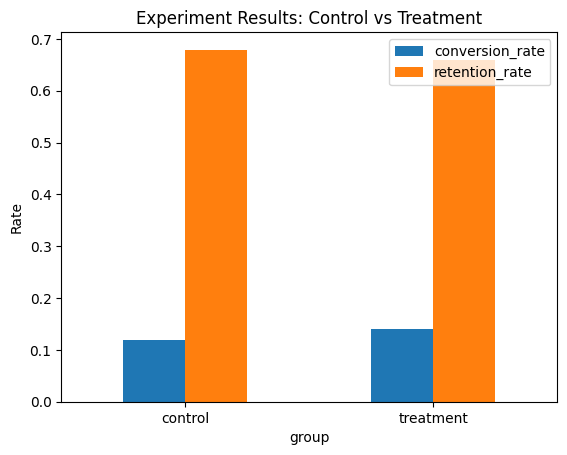

In [10]:
# Visualize conversion + retention
import matplotlib.pyplot as plt

metrics = ["conversion_rate", "retention_rate"]

plot_df = summary[metrics]

plot_df.plot(kind="bar")

plt.title("Experiment Results: Control vs Treatment")
plt.ylabel("Rate")
plt.xticks(rotation=0)

plt.show()

In [11]:
# cohort analysis
# Create signup date
df["signup_date"] = pd.to_datetime("2024-01-01") + pd.to_timedelta(
    np.random.randint(0, 30, size=len(df)), unit="D"
)

# Create cohort (week)
df["cohort_week"] = df["signup_date"].dt.to_period("W").astype(str)

# Cohort retention (only converted users)
cohort = df[df["converted"] == 1].groupby(["cohort_week", "group"]).agg(
    retention_rate=("retained", "mean")
).reset_index()

print(cohort.head())

             cohort_week      group  retention_rate
0  2024-01-01/2024-01-07    control        0.675635
1  2024-01-01/2024-01-07  treatment        0.635723
2  2024-01-08/2024-01-14    control        0.698795
3  2024-01-08/2024-01-14  treatment        0.649015
4  2024-01-15/2024-01-21    control        0.683989
